# Coding 2：债券敏感性与 CAPM Beta

对应源文件：`coding_2.py`。

## 题目一：债券估值和久期

- 债券价格是未来现金流的现值。
- 当 YTM 上升时，未来现金流折现更重，债券价格下降。
- 久期衡量价格对利率变化的敏感性；票息越高、YTM 越高，久期通常越短。

In [1]:
import numpy_financial as npf

def bond_price(face_value, coupon_rate, ytm, years, frequency):
    '''用 pv 函数计算票息债价格，注意现金流符号。'''
    coupon_payment = face_value * coupon_rate / frequency
    price = -npf.pv(ytm / frequency, years * frequency, coupon_payment, face_value)
    return price

def calculate_duration(face_value, coupon_rate, ytm, years, frequency):
    '''Macaulay Duration：用每期现金流现值占比作为权重。'''
    periods = years * frequency
    coupon_payment = face_value * coupon_rate / frequency
    price = bond_price(face_value, coupon_rate, ytm, years, frequency)
    duration = 0
    for period in range(1, periods + 1):
        time = period / frequency
        cash_flow = coupon_payment + (face_value if period == periods else 0)
        weight = cash_flow / (1 + ytm / frequency) ** period / price
        duration += weight * time
    return duration

face_value = 1000
coupon_rate = 0.07
years = 10
frequency = 2
print(calculate_duration(face_value, coupon_rate, 0.05, years, frequency))
print(calculate_duration(face_value, coupon_rate, 0.08, years, frequency))

7.564844312053709
7.246493207440446


**结果复现：YTM 与久期**

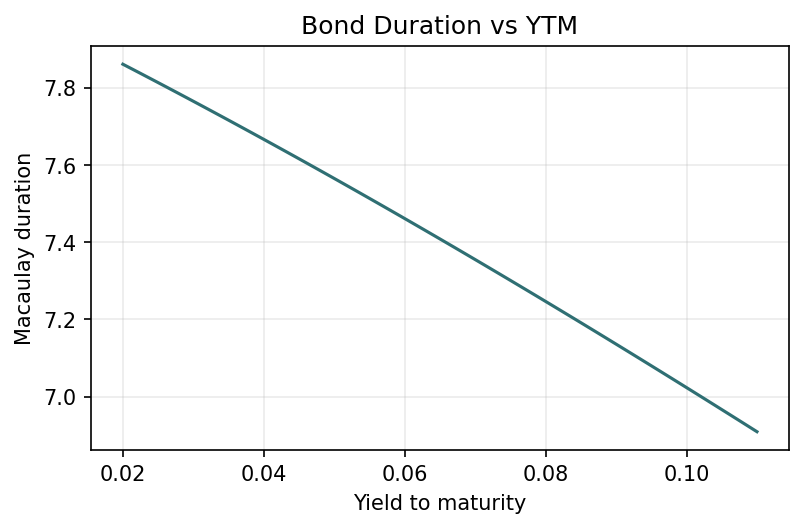

- 图体现了同一债券在不同 YTM 下的久期变化。
- 久期越长，利率变化造成的价格波动越明显。

## 题目二：科技股 CAPM Beta 估计

- 作业用 AAPL 与 S&P 500 收益率做回归。
- 回归斜率就是 AAPL 的市场 Beta。
- p 值用于判断市场收益对个股收益的解释是否显著。

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

np.random.seed(17)
dates = pd.bdate_range('2025-01-01', '2025-12-31')
market_returns = pd.Series(np.random.normal(0.0004, 0.011, len(dates)), index=dates, name='MktRet')
aapl_returns = pd.Series(0.0002 + 1.25 * market_returns + np.random.normal(0, 0.012, len(dates)), index=dates, name='AAPLret')
capm_data = pd.concat([aapl_returns, market_returns], axis=1).dropna()

'''OLS: AAPLret = alpha + beta * MktRet + error。'''
x = sm.add_constant(capm_data['MktRet'])
y = capm_data['AAPLret']
model = sm.OLS(y, x).fit()
beta = model.params['MktRet']
r_squared = model.rsquared
p_value = model.pvalues['MktRet']
print(model.summary())
print(beta, r_squared, p_value)
print('significant' if p_value < 0.05 else 'insignificant')

**结果复现：CAPM Beta**

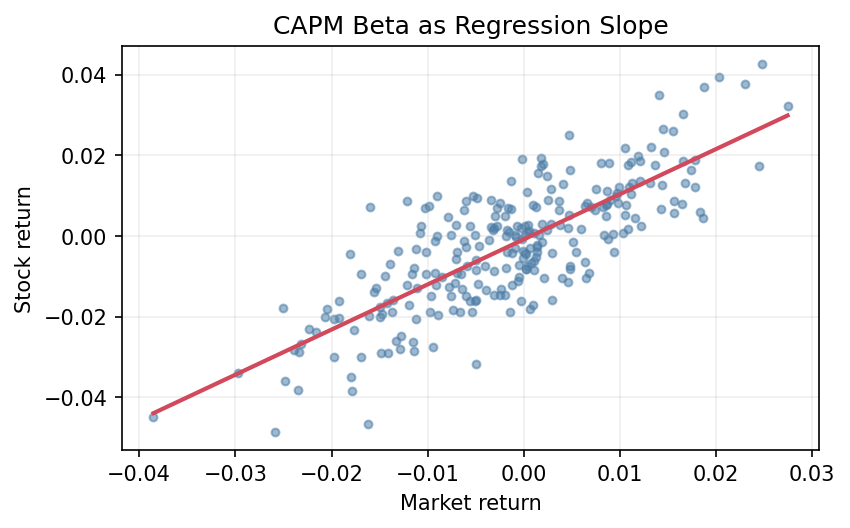

- 散点展示市场日收益和股票日收益的共同波动。
- 拟合线斜率就是 Beta；斜率越大，股票对市场涨跌越敏感。